In [2]:
import os 
os.chdir('../../')

In [3]:
from backbones.sana import SANA

# 사용 예
model = SANA(model_id='Efficient-Large-Model/Sana_600M_512px_diffusers')
print(model)

2025-09-17 16:14:59.979698: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
import matplotlib.pyplot as plt

def show_compare(imgs):
    fig, axes = plt.subplots(1, len(imgs), figsize=(18, 10))
    for i in range(len(imgs)):
        axes[i].imshow(imgs[i]); axes[i].axis('off');
    plt.tight_layout()
    plt.show()


In [5]:
PROMPTS = [
    "Historic palace courtyard at dawn; painted pillar; solemn; vermilion, jade, gold; crisp, stately; lacquer shine, carved wood",
    "Traditional tiled-roof alley in winter; paper lantern; serene; ink black, porcelain white, pine; cool, composed; mulberry paper fibers, curved tiles",
    "Volcanic island shoreline; stone guardian statue; playful; charcoal, sea teal, citrus; breezy, briny; porous rock, salt spray",
    "Temple library hall in gentle rain; woodblock page; reverent; soot, cedar, moss; quiet, ascetic; carved characters, aged pine",
    "Stepped tea fields in morning mist; woven basket; tranquil; leaf green, milky fog, earth; fresh, patient; tender leaves, damp soil ridges",
    "Lotus pond at dusk; lantern on water; reflective; moon gold, jade, indigo; still, tender; ripples, glossy petals",
    "Traditional mask workshop; painted mask; playful; birch, cinnabar, soot; lively, folkish; carved grain, silk ties",
    "Autumn ginkgo avenue; folding fan; wistful; ginkgo gold, cream, charcoal; gentle, nostalgic; leaf veins, fan ribs",
    "Mountain bell pavilion at sunrise; bronze bell; contemplative; slate, moss, peach; echoing, poised; hammered bronze, braided rope",
    "Lacquer craft studio by lamplight; mother-of-pearl panel; refined; ink black, iridescent shell; glossy, meticulous; glassy lacquer, shell shimmer",
    "Riverside night market; brass teapot; inviting; amber, olive, bronze; warm, cordial; hammered metal, wooden eaves",
    "Snow-dusted tiled roofs; paper door; hushed; snow white, charcoal, umber; soft, simple; paper lattice, frost crystals",
    "Pine-clad hillside shrine; stone pagoda; steadfast; granite gray, moss green, dusk blue; grounded, calm; chiseled stone, lichen flecks",
    "Folk festival square; ribboned drum; festive; festival red, saffron, indigo; rhythmic, buoyant; drum leather, braided sashes",
    "Windy coastal village; seaweed racks; industrious; sea teal, sand beige, charcoal; breezy, wholesome; drying strands, weathered nets",
    "Mountain valley in early spring; paper kite; hopeful; spring green, blossom pink, creek blue; airy, playful; silk ribbon, bamboo frame",
    "Wide mudflats at low tide; reed hat on post; contemplative; pewter, clay, reed green; vast, patient; sticky mud, reed stalks",
    "Ceramic kiln courtyard; celadon vase; careful; celadon green, kiln red, ash white; enduring, precise; glaze pooling, kiln ash",
    "Courtyard under first snow; strings of persimmons; homely; snow white, persimmon orange, bark brown; tender, rustic; twine knots, snow dust",
    "Summer pavilion over pond; wooden zither; graceful; pond green, lacquer black, silk cream; refined, resonant; silk strings, polished wood",
    "Hilltop pine grove; stacked stone cairn; meditative; pine green, stone gray, sky blue; resinous, calm; rough stones, needle mat",
    "Village gate at dusk; carved totem pole; protective; earth brown, soot black, rope tan; watchful, solemn; weathered wood, totem carvings",
    "Night food alley in rain; sizzling griddle; bustling; neon rose, sesame gold, steam white; savory, lively; hot oil sizzle, iron plate",
    "Cliffside pine over open sea; fisher boat; hardy; indigo sea, bone white, pine; salty, weathered; peeling paint, salt crust",
    "Harvest field at sunset; straw shoes; honest; wheat gold, clay red, slate; hardworking, warm; straw weave, grain stubble",
    "Traditional courtyard kitchen; earthen jars; communal; hearth red, soybean beige, smoke gray; hearty, stored; earthenware pores, lid rings",
    "Bamboo walkway in mist; paper umbrella; serene; mint, jade, soft gray; shaded, quiet; bamboo nodes, dew beads",
    "Mountain stream footbridge; woven sandals; steady; creek silver, fern green, wood brown; cool, firm; water-smoothed stones, moss pads",
    "Market lane in monsoon; wicker basket; intimate; rain blue, charcoal, lantern gold; humid, close; wicker weave, rain beads",
    "Academy courtyard at noon; ink brush and stone; focused; jet ink, rice white, slate; deliberate, studious; ink wash, slate slab",
]


Windy coastal village; seaweed racks; industrious; sea teal, sand beige, charcoal; breezy, wholesome; drying strands, weathered nets
logs/sana/rn/s3/step_00020000.pt


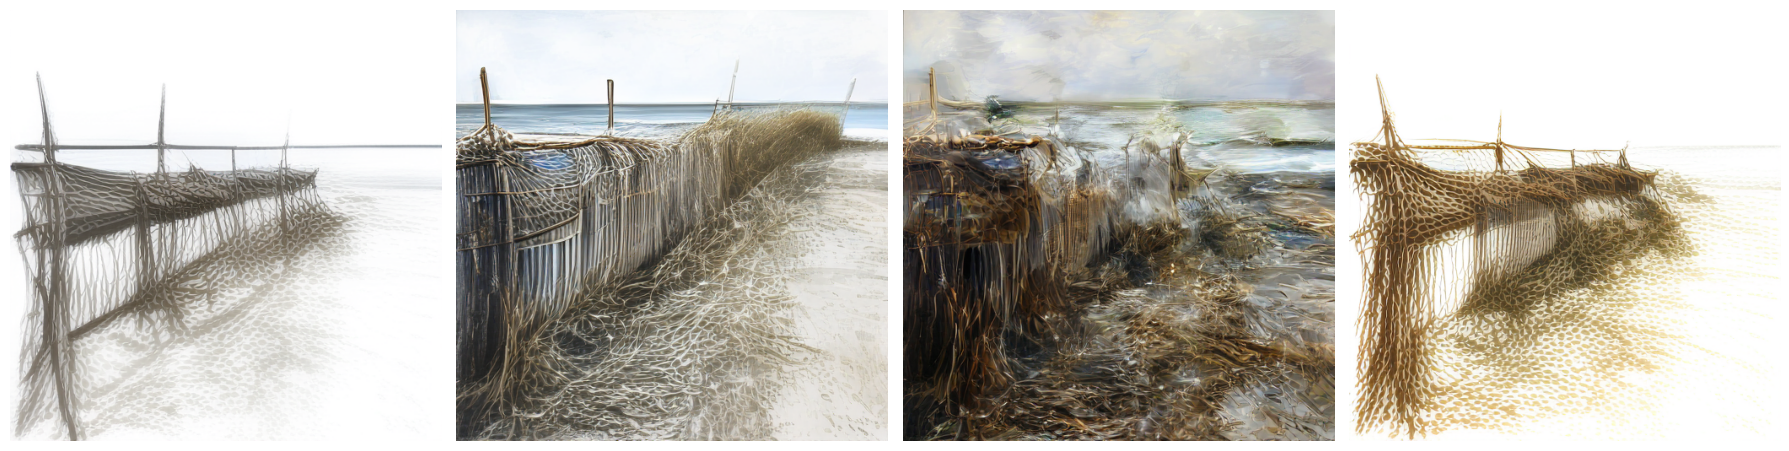

In [20]:
import torch

prompt = PROMPTS[14]
print(prompt)

noise_schedule = model.get_noise_schedule()
model_fn = model.get_model_fn(noise_schedule=noise_schedule, pos_conds=[prompt], guidance_scale=4.5)
latents = model.get_noise(seeds=[0])

NFE = 3

### DPM-Solver
from solvers.others.dpm_solver import DPM_Solver
solver = DPM_Solver(noise_schedule, steps=NFE, skip_type='time_uniform_flow', flow_shift=3.0, algorithm_type="data_prediction")
dpm_latents = solver.sample(latents, model_fn)['samples']
dpm_samples = model.decode_vae(dpm_latents, pil_output=True)

### Dual-Solver
from solvers.taylor.solver.gdual_solver import GDual_Solver
from solvers.taylor.transform.logaffine_transform import LogAffineTransform
from solvers.taylor.extractor.table_extractor import Extractor
from utils.util import get_pt

with torch.no_grad():
    gdual = GDual_Solver(noise_schedule, steps=NFE, transform=LogAffineTransform(gamma_push=True, gamma_max=2, tau_offset=1, kappa_max=2, eps=1e-2),
                        param_extractor=Extractor(steps=NFE), skip_type="time_uniform_flow", flow_shift=3.0,
                        pred_order=1, corr_order=2, order1_kappa=True, order2_kappa=True,
                        use_corrector=True, time_learning=True, train_mode=True).to(model.device)
    pt_file = get_pt(f'logs/sana/rn/s{NFE}', label='latest')
    print(pt_file)
    gdual.load_state_dict(torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict'], strict=True)
    dual_latents = gdual.sample(latents, model_fn)['samples']
    dual_samples = model.decode_vae(dual_latents, pil_output=True)

from solvers.competing.bns.bns_solver import BNS_Solver
from solvers.competing.ds.ds_solver_flow import DS_Solver

with torch.no_grad():
    bns = BNS_Solver(
                noise_schedule,
                steps=NFE,
                skip_type="time_uniform_flow",
                flow_shift=3.0,
                algorithm_type='vector_prediction'
            ).to(model.device)

    pt_file = get_pt(f'logs/sana/bns/s{NFE}/', label='latest')
    state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
    bns.load_state_dict(state_dict, strict=True)
    bns_latents = bns.sample(latents, model_fn)['samples']
    bns_samples = model.decode_vae(bns_latents, pil_output=True)
    
    ds = DS_Solver(
        noise_schedule,
        steps=NFE,
        skip_type="time_uniform_flow",
        flow_shift=3.0,
        algorithm_type='vector_prediction'
    ).to(model.device)

    pt_file = get_pt(f'logs/sana/ds/s{NFE}/', label='latest')
    state_dict = torch.load(pt_file, map_location='cpu', weights_only=False)['solver_state_dict']
    ds.load_state_dict(state_dict, strict=True)
    ds_latents = ds.sample(latents, model_fn)['samples']
    ds_samples = model.decode_vae(ds_latents, pil_output=True)
    
show_compare([dpm_samples['pil_output'][0], dual_samples['pil_output'][0], bns_samples['pil_output'][0], ds_samples['pil_output'][0]])




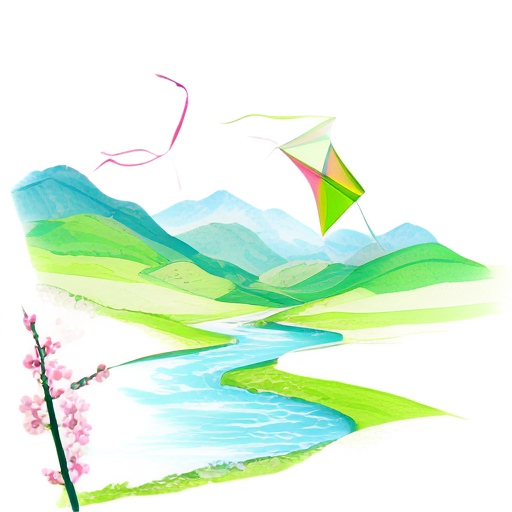

In [7]:
dpm_samples['pil_output'][0]

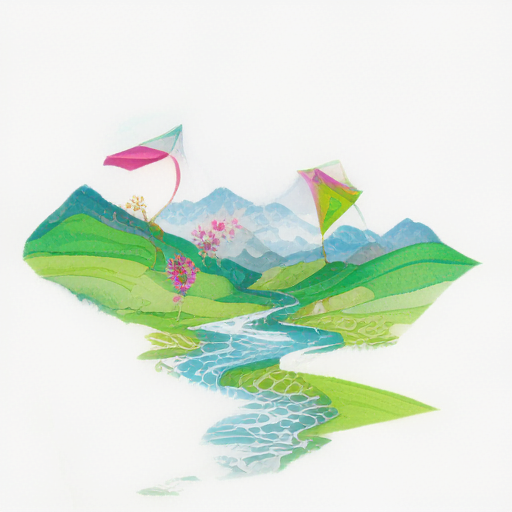

In [8]:
dual_samples['pil_output'][0]

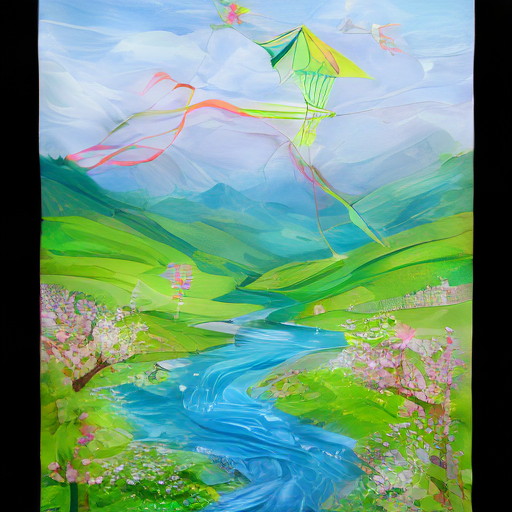

In [9]:
bns_samples['pil_output'][0]

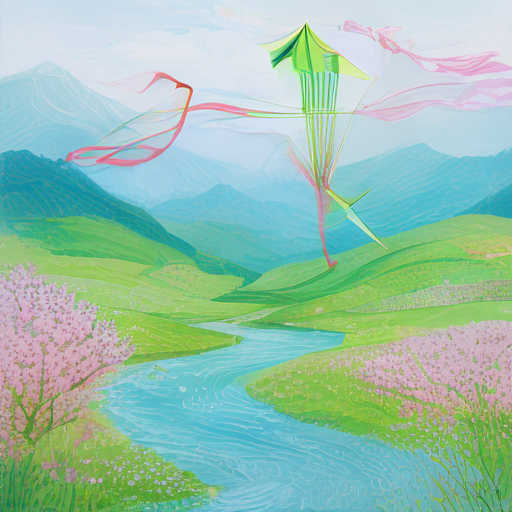

In [10]:
ds_samples['pil_output'][0]